# SPEDAC2 Multiclass Sensitivity Classification

This notebook trains and evaluates multiple classifiers (Logistic Regression, KNN, SVM,
and Transformer models) on the SPEDAC2 dataset for multiclass sensitivity detection.

---

## 1. Data Loading

Parse the WebAnno TSV training file into a DataFrame using the SPEDAC2 column format.
The macro category label is extracted from column 5 (index 4) of each token line.

In [1]:
import pandas as pd
import re
from google.colab import files



def parse_webanno_for_classification(file_path):
    """
    Parse a WebAnno TSV 3.3 file for sentence-level multiclass classification.
    Extracts the macro category label from column 5 of the first labelled token.
    Returns a DataFrame with columns: text, label.
    """
    data = []

    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Split on blank lines — each block is one sentence
    blocks = content.split('\n\n')

    for block in blocks:
        if not block.strip():
            continue

        lines = block.strip().split('\n')
        sentence_text   = None
        macro_category  = None

        for line in lines:
            if line.startswith('#Text='):
                sentence_text = line.replace('#Text=', '').strip()
            elif '\t' in line and not line.startswith('#'):
                parts = line.split('\t')
                # Column 5 (index 4) holds the macro sensitivity category
                if len(parts) >= 5 and parts[4] != '_' and parts[4].strip():
                    label = parts[4].strip()
                    match = re.match(r'([A-Za-z]+)', label)
                    if match:
                        macro_category = match.group(1)
                        break

        if sentence_text and macro_category and sentence_text != 'Sentence':
            data.append({'text': sentence_text, 'label': macro_category})

    return pd.DataFrame(data)

# Parse training split
df_train = parse_webanno_for_classification('SPEDAC2_TRAIN.tsv')
print(f'Training sentences loaded: {len(df_train)}')
df_train.head()

Training sentences loaded: 3710


,text,label
0,I'm six years survivor of this cancer after ch...,SpecialData
1,"""I tried a number of different remedies such a...",SpecialData
2,"""Because of being on a disability pension , I ...",SpecialData
3,"""For some reason, they brought a lot of cavies...",SpecialData
4,"""I am on 75mg, twice a day, tablet form My doc...",SpecialData


In [2]:
# ── Parse validation and test splits ────────────────────────────────────────
# These splits use the binary-style TSV format (label in column 4),
# so a separate parser is used.

def parse_webanno_tsv(filepath):
    """
    Parse a WebAnno TSV file where the label is in column 4 (index 3).
    Returns a list of {text, label} dicts.
    """
    sentences      = []
    current_tokens = []
    current_label  = None
    current_text   = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')

            # Skip file-level header lines
            if line.startswith('#FORMAT') or line.startswith('#T_SP'):
                continue

            # Sentence boundary
            if line.startswith('#Text='):
                current_text = line[6:]
                continue

            # Blank line = end of sentence block
            if line == '':
                if current_tokens and current_label and current_text:
                    sentences.append({'text': current_text, 'label': current_label})
                current_tokens, current_label, current_text = [], None, None
                continue

            # Token line: col[3] holds the label (e.g. 'Financial[1]')
            parts = line.split('\t')
            if len(parts) >= 4:
                token     = parts[2]
                label_raw = parts[3]
                if label_raw != '_':
                    # Strip trailing sentence-index bracket [N]
                    current_label = re.sub(r'\[\d+\]', '', label_raw)
                current_tokens.append(token)

    return sentences

df_vali = pd.DataFrame(parse_webanno_tsv('SPEDAC2_VALI.tsv'))
df_test = pd.DataFrame(parse_webanno_tsv('SPEDAC2_TEST.tsv'))

print(f'Validation sentences: {len(df_vali)}')
print(f'Test sentences:       {len(df_test)}')

Validation sentences: 410
Test sentences:       1026


## 2. Per-Split Label Overview

Quick sanity check — class counts for each original split before combining.

In [3]:
# Label distribution across all three original splits
for name, df in [('Train', df_train), ('Validation', df_vali), ('Test', df_test)]:
    print(f'\n{name} ({len(df)} sentences):')
    print(df['label'].value_counts().to_string())


Train (3710 sentences):
label
SpecialData    979
Internal       870
External       841
Social         552
Financial      468

Validation (410 sentences):
label
Social                137
SpecialData           103
External               81
Financial&Tracking     59
Internal               30

Test (1026 sentences):
label
Social                328
SpecialData           274
External              219
Financial&Tracking    122
Internal               83


## 3. Dataset Consolidation

Merge all three splits, normalise inconsistent label names, deduplicate,
and shuffle before any downstream splitting.

In [4]:
# ── Merge all splits into one master DataFrame ───────────────────────────────
combined_df_raw = pd.concat([df_train, df_vali, df_test],
                            axis=0, ignore_index=True)

print('Label counts before normalisation:')
print(combined_df_raw['label'].value_counts().to_string())

Label counts before normalisation:
label
SpecialData           1356
External              1141
Social                1017
Internal               983
Financial              468
Financial&Tracking     181


In [5]:
# ── Normalise inconsistent label names ───────────────────────────────────────
# 'Financial&Tracking' is an artefact of dual-labelling in some annotations;
# merge it into 'Financial' to keep the label space clean.
combined_df_raw['label'] = combined_df_raw['label'].replace(
    'Financial&Tracking', 'Financial'
)
combined_df_raw['label'] = combined_df_raw['label'].replace(
    'Internal', 'Internal&Social'
)
combined_df_raw['label'] = combined_df_raw['label'].replace(
    'Social', 'Internal&Social'
)

print('Label counts after normalisation:')
print(combined_df_raw['label'].value_counts().to_string())

Label counts after normalisation:
label
Internal&Social    2000
SpecialData        1356
External           1141
Financial           649


In [6]:
# ── Global deduplication and shuffle ────────────────────────────────────────
# Drop exact-text duplicates that span splits — keeps first occurrence.
combined_df = combined_df_raw.drop_duplicates(subset='text', keep='first')

# Shuffle so class order is random before any downstream splitting
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Persist combined dataset for reference
combined_df.to_csv('combined_dataset.csv', index=False)

print(f'Combined dataset size after dedup: {len(combined_df)}')
print(combined_df['label'].value_counts().to_string())

Combined dataset size after dedup: 5125
label
Internal&Social    1990
SpecialData        1356
External           1130
Financial           649


## 4. Data Exploration

Visualise class balance, per-class sentence length distributions (word and character level),
and descriptive statistics. The 95th-percentile word count informs the `max_length`
choice for transformer tokenisation.

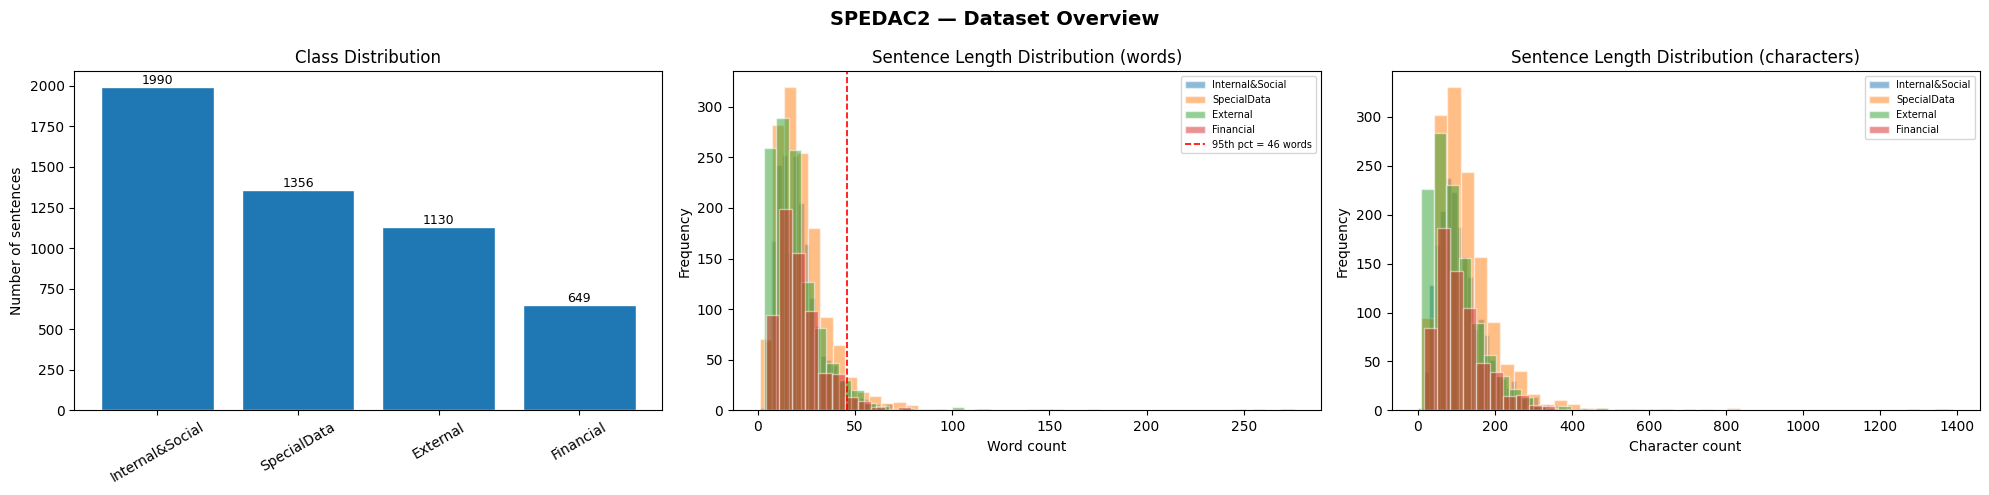

Word-count statistics per class:
                  count  mean   std  min   25%   50%   75%    max
label                                                            
External         1130.0  19.3  15.4  3.0  10.0  16.0  24.0  261.0
Financial         649.0  21.7  15.7  4.0  13.0  19.0  27.0  276.0
Internal&Social  1990.0  21.1  12.0  1.0  13.0  19.0  26.0  114.0
SpecialData      1356.0  23.1  16.2  1.0  13.0  20.0  28.0  251.0

95th percentile word count: 46 (use as transformer max_length guide)


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ── 4a. Class balance ────────────────────────────────────────────────────────
label_counts = combined_df['label'].value_counts()
n_classes    = len(label_counts)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('SPEDAC2 — Dataset Overview', fontsize=14, fontweight='bold')

# Bar chart: one bar per sensitivity category
bars = axes[0].bar(label_counts.index, label_counts.values, edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of sentences')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=9)

# ── 4b. Word-count distribution per class ────────────────────────────────────
combined_df['word_count'] = combined_df['text'].str.split().str.len()

for label in label_counts.index:
    subset = combined_df[combined_df['label'] == label]['word_count']
    axes[1].hist(subset, bins=40, alpha=0.5, label=label, edgecolor='white')

# Red dashed line at 95th percentile — guides max_length selection
p95_words = int(np.percentile(combined_df['word_count'], 95))
axes[1].axvline(p95_words, color='red', linestyle='--', linewidth=1.2,
                label=f'95th pct = {p95_words} words')
axes[1].set_title('Sentence Length Distribution (words)')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=7)

# ── 4c. Character-count distribution per class ───────────────────────────────
combined_df['char_count'] = combined_df['text'].str.len()

for label in label_counts.index:
    subset = combined_df[combined_df['label'] == label]['char_count']
    axes[2].hist(subset, bins=40, alpha=0.5, label=label, edgecolor='white')

axes[2].set_title('Sentence Length Distribution (characters)')
axes[2].set_xlabel('Character count')
axes[2].set_ylabel('Frequency')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

# ── 4d. Descriptive statistics ───────────────────────────────────────────────
print('Word-count statistics per class:')
print(combined_df.groupby('label')['word_count'].describe().round(1).to_string())
print(f'\n95th percentile word count: {p95_words} (use as transformer max_length guide)')

## 5. Label Encoding & Evaluation Helper

Encode string labels to integers with `LabelEncoder`.
The `evaluate()` function provides a unified metric report used by every model.
For multiclass tasks there is no single positive class, so per-class F1 is
reported via the full `classification_report` rather than a single `f1_sensitive`.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def evaluate(name, y_true, y_pred, label_encoder):
    """
    Compute and print a full metric summary for a multiclass classifier.

    Parameters
    ----------
    name          : display name for this model
    y_true        : ground-truth encoded labels
    y_pred        : predicted encoded labels
    label_encoder : fitted LabelEncoder — used for class names in the report

    Returns
    -------
    dict with accuracy, macro F1, and weighted F1 — appended to all_results
    """
    results = {
        'model':       name,
        'accuracy':    round(accuracy_score(y_true, y_pred) * 100, 2),
        'f1_macro':    round(f1_score(y_true, y_pred, average='macro',
                                      zero_division=0) * 100, 2),
        'f1_weighted': round(f1_score(y_true, y_pred, average='weighted',
                                      zero_division=0) * 100, 2),
    }
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy:     {results['accuracy']}%")
    print(f"  Macro F1:     {results['f1_macro']}%")
    print(f"  Weighted F1:  {results['f1_weighted']}%")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0)}")

    # Confusion matrix
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return results

# Accumulates one dict per model; used for the final comparison table
all_results = []

In [9]:
from sklearn.preprocessing import LabelEncoder

# Fit encoder on the combined label column
# LabelEncoder assigns labels in alphabetical order
le = LabelEncoder()
combined_df['label_encoded'] = le.fit_transform(combined_df['label'])

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print(f'Number of classes: {len(le.classes_)}')

# X is the raw text Series; y is the integer-encoded label Series
X = combined_df['text']
y = combined_df['label_encoded']

print('\nClass counts (encoded):')
print(combined_df['label_encoded'].value_counts().to_string())

Label mapping: {'External': np.int64(0), 'Financial': np.int64(1), 'Internal&Social': np.int64(2), 'SpecialData': np.int64(3)}
Number of classes: 4

Class counts (encoded):
label_encoded
2    1990
3    1356
0    1130
1     649


## 6. Train / Test Split

Stratified 70/30 split on the combined dataset.
Stratification preserves the class ratio for all categories in both subsets.

In [10]:
from sklearn.model_selection import train_test_split

# Stratify on encoded labels to preserve per-class proportions
train_df, test_df = train_test_split(
    combined_df,
    test_size=0.3,
    stratify=combined_df['label_encoded'],
    random_state=42
)

y_train = train_df['label_encoded']
y_test  = test_df['label_encoded']

print(f'Train size: {len(train_df)}')
print(f'Test size:  {len(test_df)}')
print('\nTrain class distribution:')
print(y_train.value_counts().to_string())
print('\nTest class distribution:')
print(y_test.value_counts().to_string())

Train size: 3587
Test size:  1538

Train class distribution:
label_encoded
2    1393
3     949
0     791
1     454

Test class distribution:
label_encoded
2    597
3    407
0    339
1    195


## 7. BOW Vectorisation

Unigram Bag-of-Words using `CountVectorizer` with built-in English stopword removal
and minimum document frequency filtering.
The vectorizer is **fitted on the training set only** to prevent vocabulary leakage.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# max_features caps vocabulary size for speed; min_df drops very rare words
# that are unlikely to generalise across splits
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=5
)

# fit_transform on train: learns vocabulary and encodes
X_train = vectorizer.fit_transform(train_df['text'])

# transform only on test: uses the training vocabulary — NO fit
X_test  = vectorizer.transform(test_df['text'])

print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'Train matrix:    {X_train.shape}')
print(f'Test matrix:     {X_test.shape}')

Vocabulary size: 1291
Train matrix:    (3587, 1291)
Test matrix:     (1538, 1291)


## 8. Top Vocabulary Words

Most frequent terms in the training BOW matrix — useful for a quick
sanity check that the vocabulary reflects the domain.

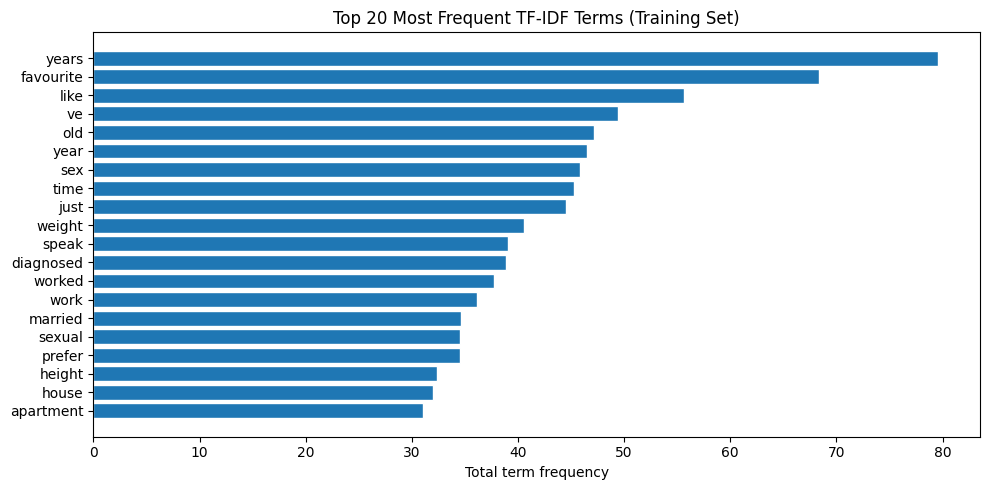

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Sum term frequencies across all training documents
feature_names = vectorizer.get_feature_names_out()
tfidf_sum = np.asarray(X_train.sum(axis=0)).flatten()

# Select the 20 highest-frequency terms
top_indices = tfidf_sum.argsort()[-20:]
top_words = feature_names[top_indices]
top_scores = tfidf_sum[top_indices]

plt.figure(figsize=(10, 5))
plt.barh(top_words, top_scores, edgecolor='white')
plt.title('Top 20 Most Frequent TF-IDF Terms (Training Set)')
plt.xlabel('Total term frequency')
plt.tight_layout()
plt.show()


## 9. Logistic Regression (no regularisation tuning)

Baseline LR with default `C=1.0`. Provides a reference point before
cross-validated regularisation is applied.


  Logistic Regression (no CV)
  Accuracy:     88.75%
  Macro F1:     88.06%
  Weighted F1:  88.67%

                 precision    recall  f1-score   support

       External       0.93      0.82      0.87       339
      Financial       0.97      0.75      0.85       195
Internal&Social       0.83      0.97      0.89       597
    SpecialData       0.93      0.89      0.91       407

       accuracy                           0.89      1538
      macro avg       0.92      0.86      0.88      1538
   weighted avg       0.90      0.89      0.89      1538



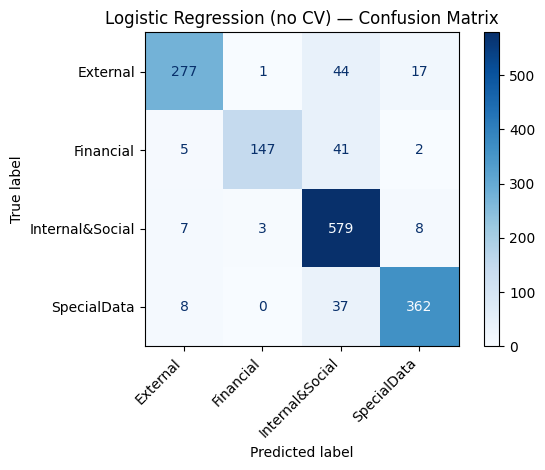

In [13]:
from sklearn.linear_model import LogisticRegression

# Default C=1.0 — no hyperparameter search, quick baseline
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

all_results.append(evaluate('Logistic Regression (no CV)', y_test, y_pred, le))

## 10. Logistic Regression with Cross-Validated Regularisation

`LogisticRegressionCV` searches a log-spaced C grid using 5-fold CV,
selecting the C that maximises macro F1.

Fitting LogisticRegressionCV...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.9s finished


Best C per class:   [21.5443469 21.5443469 21.5443469 21.5443469]

  Logistic Regression (CV)
  Accuracy:     90.64%
  Macro F1:     90.27%
  Weighted F1:  90.62%

                 precision    recall  f1-score   support

       External       0.90      0.89      0.89       339
      Financial       0.94      0.85      0.89       195
Internal&Social       0.88      0.94      0.91       597
    SpecialData       0.94      0.90      0.92       407

       accuracy                           0.91      1538
      macro avg       0.91      0.89      0.90      1538
   weighted avg       0.91      0.91      0.91      1538



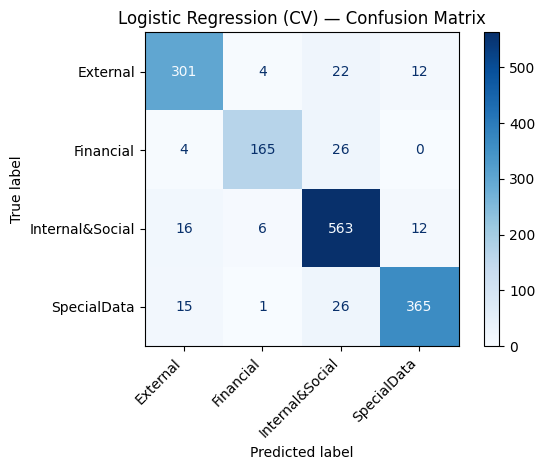

In [14]:
from sklearn.linear_model import LogisticRegressionCV
import numpy as np

# Log-spaced C grid: small C = strong regularisation, large C = weak
Cs = np.logspace(-4, 4, 10)

model_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=5,               # 5-fold cross-validation
    scoring='f1_macro', # optimise for macro F1
    max_iter=1000,
    random_state=42,
    n_jobs=-1,          # parallelise across all CPU cores
    verbose=1
)

print('Fitting LogisticRegressionCV...')
model_cv.fit(X_train, y_train)

print(f'Best C per class:   {model_cv.C_}')

y_pred_cv = model_cv.predict(X_test)

all_results.append(evaluate('Logistic Regression (CV)', y_test, y_pred_cv, le))

## 11. K-Nearest Neighbours with Grid Search

KNN with `GridSearchCV` over K, weighting scheme, and distance metric.
Included for completeness; typically underperforms LR/SVM on sparse BOW.

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'metric': 'cosine', 'n_neighbors': 21, 'weights': 'distance'}
Best CV F1:  0.8744

  KNN
  Accuracy:     86.28%
  Macro F1:     85.75%
  Weighted F1:  86.22%

                 precision    recall  f1-score   support

       External       0.89      0.81      0.85       339
      Financial       0.94      0.75      0.84       195
Internal&Social       0.81      0.95      0.87       597
    SpecialData       0.92      0.83      0.87       407

       accuracy                           0.86      1538
      macro avg       0.89      0.84      0.86      1538
   weighted avg       0.87      0.86      0.86      1538



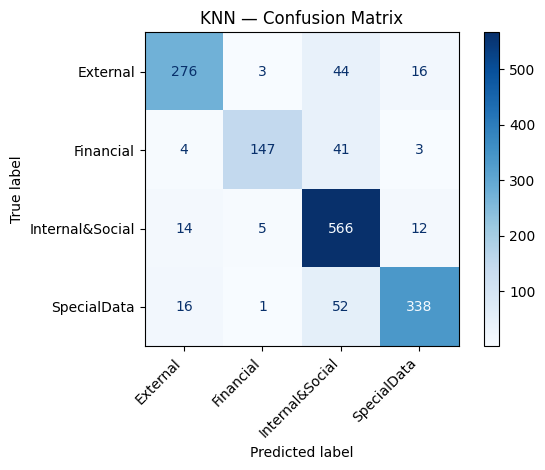

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Compact grid — odd K values avoid ties; cosine suits sparse high-dim BOW
param_grid = {
    'n_neighbors': [5, 11, 21, 31],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'cosine']
}

knn_cv = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

knn_cv.fit(X_train, y_train)

print(f'Best Params: {knn_cv.best_params_}')
print(f'Best CV F1:  {knn_cv.best_score_:.4f}')

y_pred_knn = knn_cv.predict(X_test)

all_results.append(evaluate('KNN', y_test, y_pred_knn, le))

## 12. Linear SVM with L1/L2 Regularisation

`LinearSVC` with `GridSearchCV` over C and penalty type.
L1 induces sparsity (useful for feature selection on BOW);
L2 is the standard Tikhonov regulariser.
`LinearSVC` does not support `predict_proba`.

Fitting Linear SVM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': np.float64(2.782559402207126), 'dual': False, 'penalty': 'l1'}
Best CV F1:      0.9144

  SVM (LinearSVC)
  Accuracy:     91.22%
  Macro F1:     90.99%
  Weighted F1:  91.23%

                 precision    recall  f1-score   support

       External       0.89      0.90      0.89       339
      Financial       0.93      0.89      0.91       195
Internal&Social       0.90      0.93      0.92       597
    SpecialData       0.94      0.90      0.92       407

       accuracy                           0.91      1538
      macro avg       0.91      0.91      0.91      1538
   weighted avg       0.91      0.91      0.91      1538



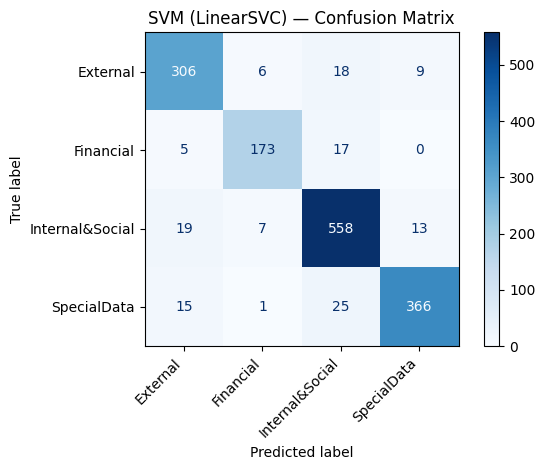

In [16]:
from sklearn.svm import LinearSVC
import numpy as np

# Search over regularisation strength and penalty type
# dual=False is required when penalty='l1'
param_grid_linear = {
    'C':       np.logspace(-4, 4, 10),
    'penalty': ['l1', 'l2'],
    'dual':    [False]
}

linear_svm = GridSearchCV(
    LinearSVC(random_state=42, max_iter=5000),
    param_grid_linear,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print('Fitting Linear SVM...')
linear_svm.fit(X_train, y_train)

print(f'Best Parameters: {linear_svm.best_params_}')
print(f'Best CV F1:      {linear_svm.best_score_:.4f}')

y_pred_linear = linear_svm.predict(X_test)

# LinearSVC has no predict_proba — confusion matrix shown via evaluate()
all_results.append(evaluate('SVM (LinearSVC)', y_test, y_pred_linear, le))

## 13. Classical Models — Results Summary

Aggregated metrics for all BOW-based models, ranked by macro F1.


CLASSICAL MODELS — FINAL RESULTS
                      model  accuracy  f1_macro  f1_weighted
            SVM (LinearSVC)     91.22     90.99        91.23
   Logistic Regression (CV)     90.64     90.27        90.62
Logistic Regression (no CV)     88.75     88.06        88.67
                        KNN     86.28     85.75        86.22


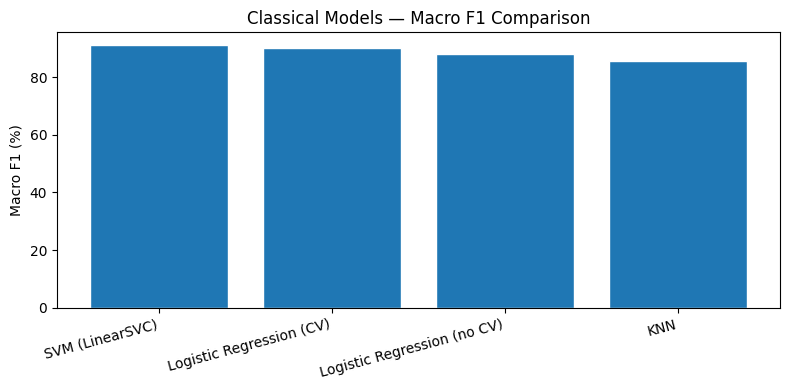

In [17]:
import pandas as pd

# Build comparison table from results accumulated by evaluate()
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('f1_macro', ascending=False)

print('\n' + '='*55)
print('CLASSICAL MODELS — FINAL RESULTS')
print('='*55)
print(results_df[['model', 'accuracy', 'f1_macro', 'f1_weighted']].to_string(index=False))

# Bar chart comparison of macro F1 across models
plt.figure(figsize=(8, 4))
plt.bar(results_df['model'], results_df['f1_macro'], edgecolor='white')
plt.title('Classical Models — Macro F1 Comparison')
plt.ylabel('Macro F1 (%)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

results_df.to_csv('spedac2_results_classical.csv', index=False)

## 14. Transformer Fine-Tuning

Four pre-trained transformers are fine-tuned for multiclass classification.
`num_labels` is set to the number of distinct categories in the dataset.

| Model | Notes |
|---|---|
| `distilbert-base-uncased` | Lightweight, fast baseline transformer |
| `roberta-base` | Strong English encoder |
| `sentence-transformers/LaBSE` | Multilingual; `ignore_mismatched_sizes=True` required |
| `microsoft/deberta-base` | Disentangled attention; `fp16` disabled due to overflow bug |

A 10% validation slice is carved from the training portion for early stopping.


Training DistilBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  DistilBERT
  Accuracy:     95.51%
  Macro F1:     95.77%
  Weighted F1:  95.51%

                 precision    recall  f1-score   support

       External       0.97      0.92      0.95       339
      Financial       0.98      0.97      0.98       195
Internal&Social       0.95      0.97      0.96       597
    SpecialData       0.94      0.96      0.95       407

       accuracy                           0.96      1538
      macro avg       0.96      0.95      0.96      1538
   weighted avg       0.96      0.96      0.96      1538



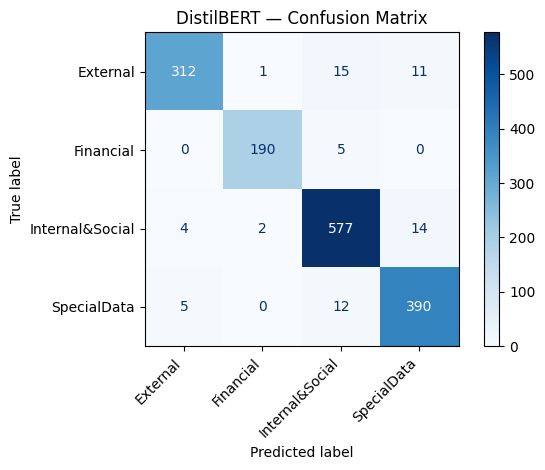

  Done — DistilBERT results saved.

Training RoBERTa...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


  RoBERTa
  Accuracy:     95.71%
  Macro F1:     95.79%
  Weighted F1:  95.71%

                 precision    recall  f1-score   support

       External       0.97      0.93      0.95       339
      Financial       0.97      0.96      0.97       195
Internal&Social       0.95      0.97      0.96       597
    SpecialData       0.95      0.96      0.95       407

       accuracy                           0.96      1538
      macro avg       0.96      0.96      0.96      1538
   weighted avg       0.96      0.96      0.96      1538



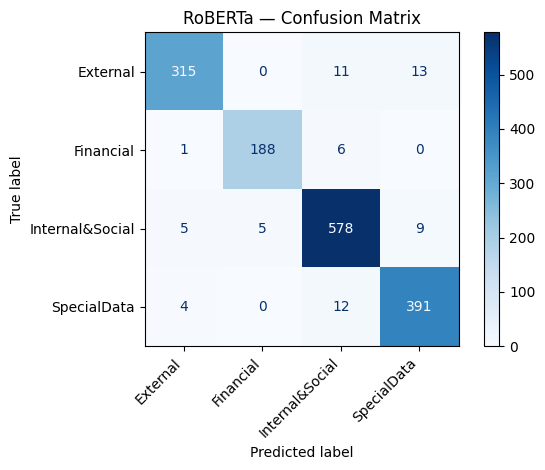

  Done — RoBERTa results saved.

Training LaBSE...


config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/397 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


  LaBSE
  Accuracy:     96.1%
  Macro F1:     96.19%
  Weighted F1:  96.1%

                 precision    recall  f1-score   support

       External       0.95      0.95      0.95       339
      Financial       0.99      0.96      0.97       195
Internal&Social       0.96      0.97      0.96       597
    SpecialData       0.96      0.96      0.96       407

       accuracy                           0.96      1538
      macro avg       0.96      0.96      0.96      1538
   weighted avg       0.96      0.96      0.96      1538



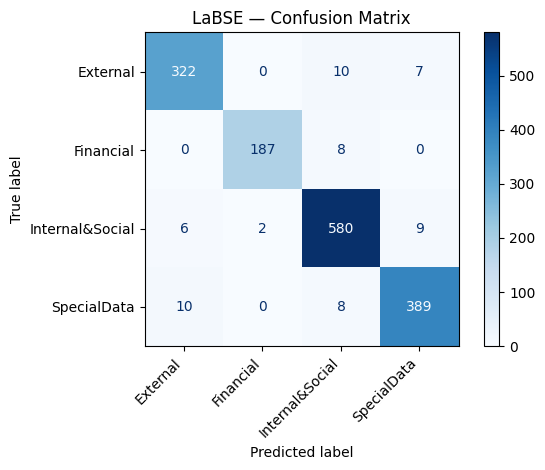

  Done — LaBSE results saved.

Training DeBERTa-base...


config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


  DeBERTa-base
  Accuracy:     94.93%
  Macro F1:     94.92%
  Weighted F1:  94.93%

                 precision    recall  f1-score   support

       External       0.94      0.94      0.94       339
      Financial       0.96      0.95      0.96       195
Internal&Social       0.95      0.96      0.95       597
    SpecialData       0.95      0.94      0.95       407

       accuracy                           0.95      1538
      macro avg       0.95      0.95      0.95      1538
   weighted avg       0.95      0.95      0.95      1538



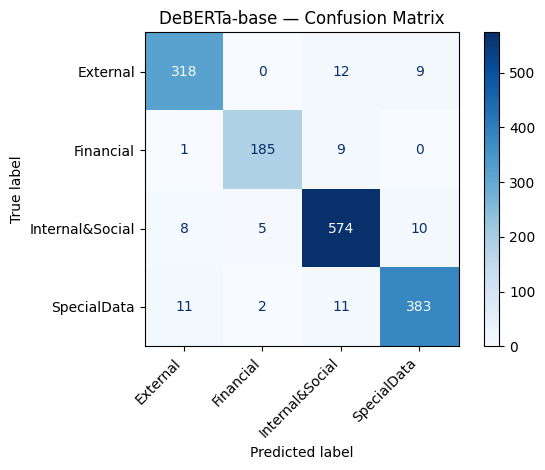

  Done — DeBERTa-base results saved.

ALL MODELS — FINAL RESULTS
                      model  accuracy  f1_macro  f1_weighted
                      LaBSE     96.10     96.19        96.10
                    RoBERTa     95.71     95.79        95.71
                 DistilBERT     95.51     95.77        95.51
               DeBERTa-base     94.93     94.92        94.93
            SVM (LinearSVC)     91.22     90.99        91.23
   Logistic Regression (CV)     90.64     90.27        90.62
Logistic Regression (no CV)     88.75     88.06        88.67
                        KNN     86.28     85.75        86.22


In [18]:
import torch
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ── Rebuild plain-text splits ────────────────────────────────────────────────
text_series  = combined_df['text'].reset_index(drop=True)
label_series = combined_df['label_encoded'].reset_index(drop=True)

NUM_LABELS = len(le.classes_)

text_train, text_test, label_train, label_test = train_test_split(
    text_series, label_series,
    test_size=0.3, random_state=42, stratify=label_series
)
text_train, text_val, label_train, label_val = train_test_split(
    text_train, label_train,
    test_size=0.1, random_state=42, stratify=label_train
)

text_train  = text_train.reset_index(drop=True)
text_val    = text_val.reset_index(drop=True)
text_test   = text_test.reset_index(drop=True)
label_train = label_train.reset_index(drop=True)
label_val   = label_val.reset_index(drop=True)
label_test  = label_test.reset_index(drop=True)

# ── Class weights — computed once, reused for all models ─────────────────────
class_weights  = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(label_train),
    y=label_train
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# ── WeightedTrainer — defined once, outside the loop ─────────────────────────
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get('labels')
        outputs = model(**inputs)
        logits  = outputs.get('logits')
        loss    = torch.nn.functional.cross_entropy(
            logits, labels,
            weight=weights_tensor.to(logits.device)
        )
        return (loss, outputs) if return_outputs else loss

def make_hf_dataset(texts, labels, tokenizer, max_length=128):
    ds = Dataset.from_dict({'text': texts.tolist(), 'label': labels.tolist()})
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True,
                         padding='max_length', max_length=max_length)
    return ds.map(tokenize, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': round(accuracy_score(labels, preds) * 100, 2),
        'f1_macro': round(f1_score(labels, preds, average='macro',
                                   zero_division=0) * 100, 2)
    }

TRANSFORMER_MODELS = {
    'DistilBERT':   'distilbert-base-uncased',
    'RoBERTa':      'roberta-base',
    'LaBSE':        'sentence-transformers/LaBSE',
    'DeBERTa-base': 'microsoft/deberta-base',
}

# ── Training loop ─────────────────────────────────────────────────────────────
for model_name, model_path in TRANSFORMER_MODELS.items():
    print(f"\n{'='*50}\nTraining {model_name}...\n{'='*50}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tfr_model = AutoModelForSequenceClassification.from_pretrained(
                    model_path, num_labels=NUM_LABELS,
                    ignore_mismatched_sizes=True)

    train_ds = make_hf_dataset(text_train, label_train, tokenizer)
    val_ds   = make_hf_dataset(text_val,   label_val,   tokenizer)
    test_ds  = make_hf_dataset(text_test,  label_test,  tokenizer)

    args = TrainingArguments(
        output_dir                  = f'./results/{model_name}',
        learning_rate               = 3e-5,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        num_train_epochs            = 3,
        weight_decay                = 0.01,
        warmup_ratio                = 0.1,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1_macro',
        logging_steps               = 50,
        fp16                        = torch.cuda.is_available() and model_name != 'DeBERTa-base',
        seed                        = 42,
    )

    trainer = WeightedTrainer(
        model           = tfr_model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
    )

    trainer.train()

    preds_output = trainer.predict(test_ds)
    logits       = preds_output.predictions
    y_pred_tr    = np.argmax(logits, axis=-1)

    all_results.append(evaluate(model_name, label_test, y_pred_tr, le))
    print(f'  Done — {model_name} results saved.')

# ── Final combined results table ──────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('f1_macro', ascending=False)
print('\n' + '='*55)
print('ALL MODELS — FINAL RESULTS')
print('='*55)
print(results_df[['model', 'accuracy', 'f1_macro', 'f1_weighted']].to_string(index=False))
results_df.to_csv('spedac2_results_all.csv', index=False)

In [19]:
def colab2pdf():
  ENABLE=True # @param {type:"boolean"}
  if ENABLE:
    !apt-get install librsvg2-bin
    import os, datetime, json, locale, pathlib, urllib, requests, werkzeug, nbformat, google, yaml, warnings
    locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
    NAME = pathlib.Path(werkzeug.utils.secure_filename(urllib.parse.unquote(requests.get(f"http://{os.environ['COLAB_JUPYTER_IP']}:{os.environ['KMP_TARGET_PORT']}/api/sessions").json()[0]["name"])))
    TEMP = pathlib.Path("/content/pdfs") / f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{NAME.stem}"; TEMP.mkdir(parents=True, exist_ok=True)
    NB = [cell for cell in nbformat.reads(json.dumps(google.colab._message.blocking_request("get_ipynb", timeout_sec=600)["ipynb"]), as_version=4).cells if "--Colab2PDF" not in cell.source]
    warnings.filterwarnings('ignore', category=nbformat.validator.MissingIDFieldWarning)
    with (TEMP / f"{NAME.stem}.ipynb").open("w", encoding="utf-8") as nb_copy: nbformat.write(nbformat.v4.new_notebook(cells=NB or [nbformat.v4.new_code_cell("#")]), nb_copy)
  if not pathlib.Path("/usr/local/bin/quarto").exists():
    !wget -q "https://quarto.org/download/latest/quarto-linux-amd64.deb" -P {TEMP} && dpkg -i {TEMP}/quarto-linux-amd64.deb > /dev/null && quarto install tinytex --update-path --quiet
    with (TEMP / "config.yml").open("w", encoding="utf-8") as file: yaml.dump({'include-in-header': [{"text": r"\usepackage{fvextra}\DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines,breakanywhere,commandchars=\\\{\}}"}],'include-before-body': [{"text": r"\DefineVerbatimEnvironment{verbatim}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines}"}]}, file)
    !quarto render {TEMP}/{NAME.stem}.ipynb --metadata-file={TEMP}/config.yml --to pdf -M latex-auto-install -M margin-top=1in -M margin-bottom=1in -M margin-left=1in -M margin-right=1in --quiet
    google.colab.files.download(str(TEMP / f"{NAME.stem}.pdf"))
colab2pdf()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  librsvg2-bin
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 1,871 kB of archives.
After this operation, 6,019 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 librsvg2-bin amd64 2.52.5+dfsg-3ubuntu0.2 [1,871 kB]
Fetched 1,871 kB in 1s (1,436 kB/s)
Selecting previously unselected package librsvg2-bin.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../librsvg2-bin_2.52.5+dfsg-3ubuntu0.2_amd64.deb ...
Unpacking librsvg2-bin (2.52.5+dfsg-3ubuntu0.2) ...
Setting up librsvg2-bin (2.52.5+dfsg-3ubuntu0.2) ...
Processing triggers for man-db (2.10.2-1) ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>